# 02 — Event study

Phase 3. Quantifies how the Brent–WTI spread behaves around Middle East supply shocks.

**Design.** For each event with announcement date `T`:
- **Estimation window** `[T−80, T−20]` (60 trading days) — defines the pre-event baseline mean μ and std σ of the dollar spread. It deliberately ends 20 days *before* the event so the run-up is visible rather than absorbed into the baseline.
- **Event window** `[T−20, T+60]` (81 trading days) — the displayed path.
- **Spread-z path** `z_t = (spread_t − μ) / σ` — standardised against the pre-event baseline, plotted on a common event-day axis.

Spread-z is defined on the **dollar spread** (Brent − WTI) — the tradeable quantity, and the same definition the Phase-4 backtest triggers on.

**Events (locked in ROADMAP):**

| Date | Event | Role |
|------|-------|------|
| 2019-09-16 | Aramco Abqaiq drone strike | historical comparable |
| 2020-01-03 | Soleimani assassination | historical comparable |
| 2024-01-19 | Houthi Red Sea escalation | ambient-escalation control |
| 2026-02-28 | Operation Epic Fury (conflict start) | **primary focal event, t=0** |
| 2026-03-04 | Strait of Hormuz closure | secondary anchor (supply-shock trigger) |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(REPO / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date")
df = df.sort_index()

EVENTS = {
    "Aramco 2019":   "2019-09-16",
    "Soleimani 2020": "2020-01-03",
    "Houthi 2024":   "2024-01-19",
    "Epic Fury 2026": "2026-02-28",
    "Hormuz 2026":   "2026-03-04",
}

PRE_LEN = 60     # estimation-window length (trading days)
PRE_GAP = 20     # gap between estimation window and event
WIN_PRE = 20     # event window starts T-20
WIN_POST = 60    # event window ends T+60
print(f"data {df.index.min().date()} → {df.index.max().date()}; {len(EVENTS)} events")

data 1987-05-20 → 2026-05-26; 5 events


## Build spread-z paths on a common event-day axis

In [2]:
def event_pos(date_str: str) -> int:
    """Index position of the first trading day on/after the event date."""
    return int(df.index.searchsorted(pd.Timestamp(date_str)))


offsets = np.arange(-WIN_PRE, WIN_POST + 1)
z_paths = pd.DataFrame(index=offsets)
spread_paths = pd.DataFrame(index=offsets)
baselines = {}

for name, date_str in EVENTS.items():
    pos = event_pos(date_str)
    # Estimation window [T-80, T-20): mean/std of the dollar spread.
    est = df["spread"].iloc[pos - PRE_GAP - PRE_LEN : pos - PRE_GAP]
    mu, sigma = est.mean(), est.std(ddof=1)
    baselines[name] = {"baseline μ": mu, "baseline σ": sigma}

    lo, hi = pos - WIN_PRE, pos + WIN_POST + 1
    window = df["spread"].iloc[max(lo, 0):min(hi, len(df))]
    rel = np.arange(len(df))[max(lo, 0):min(hi, len(df))] - pos  # event-day offsets

    s = pd.Series(window.values, index=rel)
    spread_paths[name] = s.reindex(offsets)
    z_paths[name] = (s.reindex(offsets) - mu) / sigma

pd.DataFrame(baselines).T.round(2)

,baseline μ,baseline σ
Aramco 2019,7.63,2.73
Soleimani 2020,6.07,0.72
Houthi 2024,5.05,0.91
Epic Fury 2026,4.87,1.47
Hormuz 2026,4.98,1.51


In [3]:
# Coverage check — 2026 events have truncated forward windows (data ends 2026-05-26)
coverage = z_paths.notna().sum().to_frame("days covered (of 81)")
coverage["last offset"] = [z_paths[c].last_valid_index() for c in z_paths.columns]
coverage

,days covered (of 81),last offset
Aramco 2019,81,60
Soleimani 2020,81,60
Houthi 2024,81,60
Epic Fury 2026,78,57
Hormuz 2026,76,55


## Per-event metrics

For each event: the pre-event baseline, the peak spread-z reached after t=0, how fast it got there, and how long it took to renormalise (first return to |z|<1 after the peak). Pre/post volatility captures whether the shock left the spread structurally more variable.

In [4]:
def event_metrics(name: str) -> dict:
    z = z_paths[name]
    post = z[z.index >= 0].dropna()
    # peak = largest absolute deviation after the event
    peak_off = post.abs().idxmax()
    peak_z = post.loc[peak_off]
    # days to renormalise: first offset after the peak where |z| < 1
    after_peak = z[(z.index > peak_off)].dropna()
    renorm = after_peak[after_peak.abs() < 1]
    days_to_renorm = int(renorm.index[0]) if len(renorm) else np.nan

    sp = spread_paths[name]
    pre_vol = sp[sp.index < 0].std(ddof=1)
    post_vol = sp[sp.index >= 0].std(ddof=1)
    return {
        "peak |z|": round(abs(peak_z), 2),
        "peak z (signed)": round(peak_z, 2),
        "days to peak": int(peak_off),
        "days to renorm": days_to_renorm,
        "pre vol ($)": round(pre_vol, 2),
        "post vol ($)": round(post_vol, 2),
        "vol ratio": round(post_vol / pre_vol, 2),
    }


metrics = pd.DataFrame({n: event_metrics(n) for n in EVENTS}).T
metrics

,peak |z|,peak z (signed),days to peak,days to renorm,pre vol ($),post vol ($),vol ratio
Aramco 2019,1.29,-1.29,34.0,35.0,1.30,0.76,0.59
Soleimani 2020,16.27,-16.27,60.0,NaN,0.66,2.44,3.69
Houthi 2024,3.69,-3.69,48.0,49.0,1.25,1.48,1.18
Epic Fury 2026,14.32,14.32,25.0,44.0,0.77,6.87,8.86
Hormuz 2026,13.90,13.90,23.0,42.0,0.89,6.93,7.75


## The money plot

Every event's spread-z path on one event-day axis, with the cross-event median and IQR band. This figure is the visual core of the paper: it shows whether supply shocks produce a *characteristic* spread response and on what timescale it reverts.

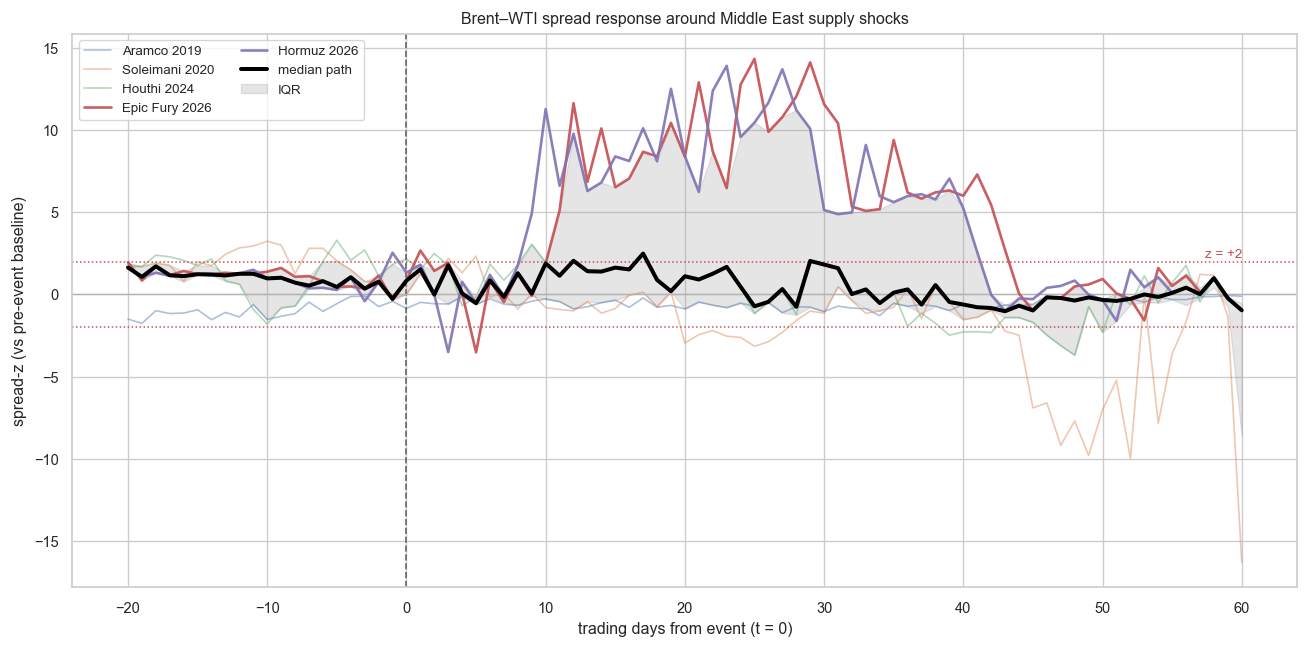

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# individual event paths (faint)
for name in EVENTS:
    is_2026 = "2026" in name
    ax.plot(z_paths.index, z_paths[name], lw=1.6 if is_2026 else 1.0,
            alpha=0.9 if is_2026 else 0.45,
            label=name, zorder=3 if is_2026 else 2)

# cross-event median + IQR (historical comparables drive the band; 2026 shown on top)
median = z_paths.median(axis=1)
q25, q75 = z_paths.quantile(0.25, axis=1), z_paths.quantile(0.75, axis=1)
ax.plot(z_paths.index, median, color="black", lw=2.4, label="median path", zorder=4)
ax.fill_between(z_paths.index, q25, q75, color="0.6", alpha=0.25, label="IQR", zorder=1)

ax.axvline(0, color="0.4", ls="--", lw=1)
ax.axhline(0, color="0.7", lw=0.8)
ax.axhline(2, color="C3", ls=":", lw=0.9)
ax.axhline(-2, color="C3", ls=":", lw=0.9)
ax.text(WIN_POST, 2.05, "z = +2", color="C3", fontsize=8, ha="right", va="bottom")
ax.set_xlabel("trading days from event (t = 0)")
ax.set_ylabel("spread-z (vs pre-event baseline)")
ax.set_title("Brent–WTI spread response around Middle East supply shocks")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(REPO / "paper" / "fig_money_plot.png", bbox_inches="tight")
plt.show()

## Headline event-study numbers

For the README table and the paper's event-study paragraph. The contrast between the historical comparables (transient blow-out, reverts within weeks) and 2026 (larger, slower) is the short-vs-long-term spine of the thesis.

In [6]:
hist = metrics.loc[["Aramco 2019", "Soleimani 2020", "Houthi 2024"]]
focal = metrics.loc[["Epic Fury 2026", "Hormuz 2026"]]

summary = pd.Series({
    "Historical median peak |z|": round(hist["peak |z|"].median(), 2),
    "Historical median days-to-renorm": hist["days to renorm"].median(),
    "2026 Epic Fury peak |z|": metrics.loc["Epic Fury 2026", "peak |z|"],
    "2026 Epic Fury days-to-renorm": metrics.loc["Epic Fury 2026", "days to renorm"],
    "2026 median vol ratio (post/pre)": round(focal["vol ratio"].median(), 2),
    "Historical median vol ratio": round(hist["vol ratio"].median(), 2),
})
summary.to_frame("value")

,value
Historical median peak |z|,3.69
Historical median days-to-renorm,42.00
2026 Epic Fury peak |z|,14.32
2026 Epic Fury days-to-renorm,44.00
2026 median vol ratio (post/pre),8.30
Historical median vol ratio,1.18


> **Caveats (→ Limitations).** (1) Only 3 clean historical comparables drive the median/IQR band — small-sample, stated honestly. (2) The 2026 forward windows are **truncated** (data ends 2026-05-26), so 2026 "days-to-renorm" may be right-censored: if the spread has *not* renormalised by the data edge, that is itself the long-term-repricing signal Phase 5 tests, not a missing value to ignore. (3) Epic Fury (28 Feb) and Hormuz (4 Mar) are only ~4 trading days apart, so their windows overlap heavily — treat them as one compound 2026 episode, not two independent draws.